# Exploratory Data Analysis -- Subscription Churn (Synthetic)

This notebook explores the synthetic, telecom-style subscription customer
dataset produced by `churn.data.synthetic.generate_synthetic_customers`. The
dataset is entirely synthetic -- see that module's docstring for the exact
data-generating process. This notebook loads the data through the same
`LocalSyntheticConnector` used by the training pipeline, so what you see
here is exactly what the model trains on.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from churn.config import settings
from churn.data.connector import LocalSyntheticConnector

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4)

connector = LocalSyntheticConnector(
    cache_path=settings.raw_data_path,
    n_customers=settings.n_customers,
    seed=settings.random_seed,
)
df = connector.load_customers()
df.shape

(20000, 12)

In [2]:
df.head()

,customer_id,tenure_months,contract_type,monthly_charges,total_charges,payment_method,autopay,num_support_tickets_90d,avg_monthly_usage_gb,has_multiple_lines,is_senior,churn
0,CUST-0000000,27,one_year,69.46,1884.29,electronic_check,True,1,35.45,True,False,0
1,CUST-0000001,58,two_year,33.02,2063.02,electronic_check,False,0,19.57,False,False,0
2,CUST-0000002,41,month_to_month,64.08,2978.88,electronic_check,True,0,49.06,True,True,0
3,CUST-0000003,6,month_to_month,53.04,321.53,electronic_check,True,0,26.75,True,False,0
4,CUST-0000004,9,one_year,38.06,334.19,credit_card,True,1,9.39,False,False,0


## Overall churn rate and column overview

The generator targets a 20-30% churn rate, consistent with typical telecom
subscriber base figures reported in industry churn studies.

In [3]:
print(f"Churn rate: {df['churn'].mean():.2%}")
df.info()

Churn rate: 22.77%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              20000 non-null  object 
 1   tenure_months            20000 non-null  int64  
 2   contract_type            20000 non-null  object 
 3   monthly_charges          20000 non-null  float64
 4   total_charges            19196 non-null  float64
 5   payment_method           20000 non-null  object 
 6   autopay                  20000 non-null  bool   
 7   num_support_tickets_90d  20000 non-null  int64  
 8   avg_monthly_usage_gb     20000 non-null  float64
 9   has_multiple_lines       20000 non-null  bool   
 10  is_senior                20000 non-null  bool   
 11  churn                    20000 non-null  int64  
dtypes: bool(3), float64(3), int64(3), object(3)
memory usage: 1.4+ MB


## The `total_charges` null pattern

Customers with `tenure_months == 0` have not completed a billing cycle yet,
so `total_charges` is null for them by construction -- mirroring a
well-known quirk in real telecom billing extracts.

In [4]:
null_mask = df["total_charges"].isna()
print(f"Rows with null total_charges: {null_mask.sum()} ({null_mask.mean():.2%})")
df.loc[null_mask, "tenure_months"].describe()

Rows with null total_charges: 804 (4.02%)


count    804.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: tenure_months, dtype: float64

## Numeric feature distributions, split by churn

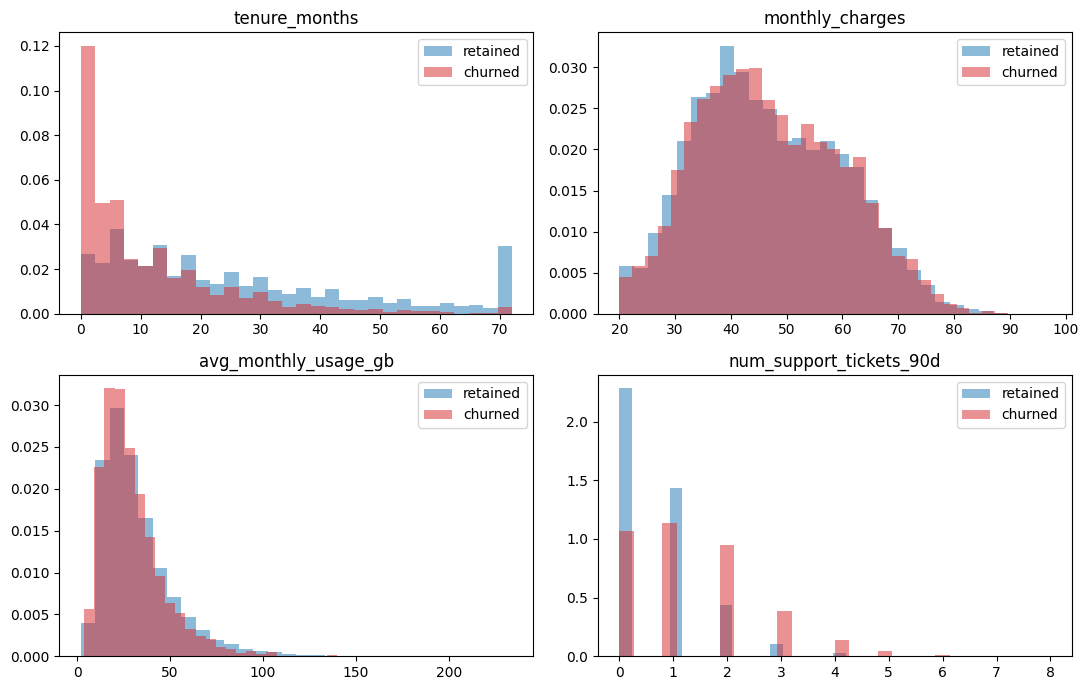

In [5]:
numeric_cols = [
    "tenure_months",
    "monthly_charges",
    "avg_monthly_usage_gb",
    "num_support_tickets_90d",
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), numeric_cols, strict=True):
    for churn_value, label, color in [(0, "retained", "tab:blue"), (1, "churned", "tab:red")]:
        subset = df.loc[df["churn"] == churn_value, col]
        ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)
    ax.set_title(col)
    ax.legend()
fig.tight_layout()
plt.show()

Churned customers skew toward shorter tenure and more support tickets, and
retained customers skew toward higher usage -- consistent with the
generator's documented data-generating process.

## Churn rate by categorical / boolean drivers

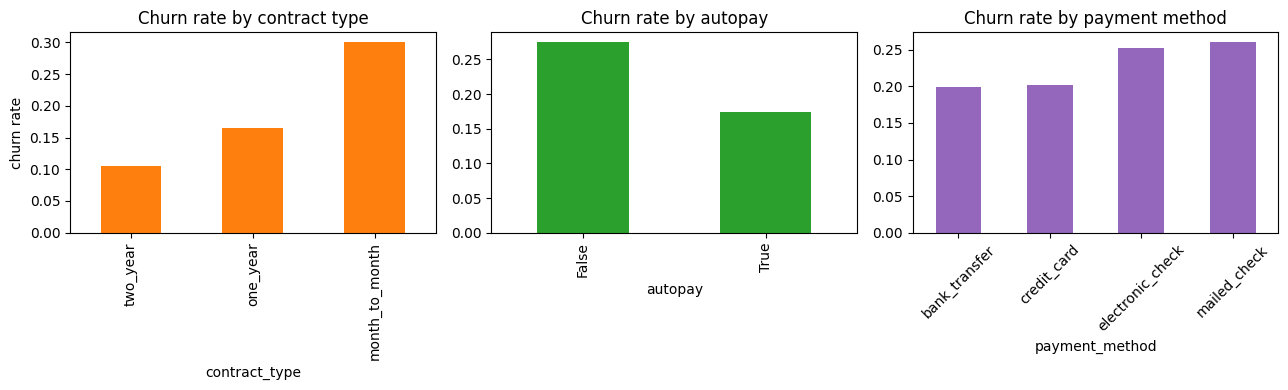

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

df.groupby("contract_type")["churn"].mean().sort_values().plot.bar(ax=axes[0], color="tab:orange")
axes[0].set_title("Churn rate by contract type")
axes[0].set_ylabel("churn rate")

df.groupby("autopay")["churn"].mean().plot.bar(ax=axes[1], color="tab:green")
axes[1].set_title("Churn rate by autopay")

df.groupby("payment_method")["churn"].mean().sort_values().plot.bar(ax=axes[2], color="tab:purple")
axes[2].set_title("Churn rate by payment method")
axes[2].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

Month-to-month contracts and non-autopay customers show a visibly higher
churn rate, as designed into the generator's logistic model.

## Correlation among numeric features

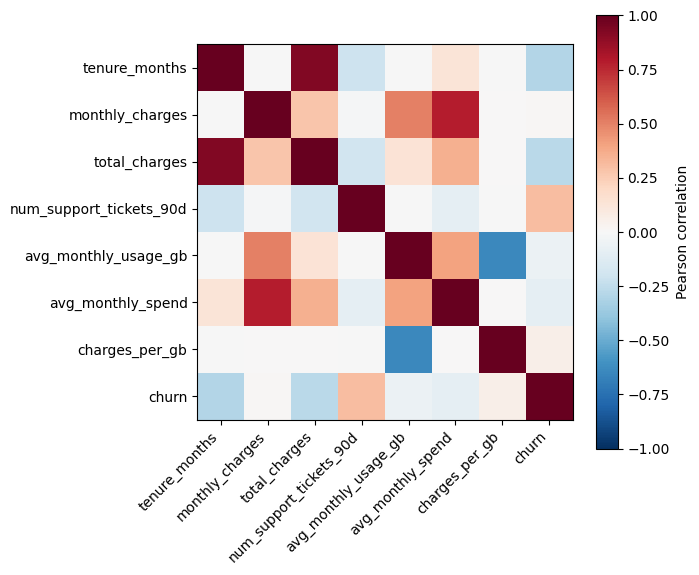

churn                      1.000000
num_support_tickets_90d    0.308074
charges_per_gb             0.057724
monthly_charges            0.013245
avg_monthly_usage_gb      -0.059623
avg_monthly_spend         -0.087127
total_charges             -0.269329
tenure_months             -0.293155
Name: churn, dtype: float64

In [7]:
from churn.features import add_derived_features

engineered = add_derived_features(df)
corr_cols = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets_90d",
    "avg_monthly_usage_gb",
    "avg_monthly_spend",
    "charges_per_gb",
    "churn",
]
corr = engineered[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
plt.show()

corr["churn"].sort_values(ascending=False)

## Summary

- Churn rate is in the documented 20-30% target range.
- `total_charges` nulls are fully explained by zero-tenure customers (see
  `churn.features.add_derived_features` for how this is handled).
- Contract type, autopay, tenure, and support-ticket volume all show the
  expected directional relationship with churn, confirming the synthetic
  generator's signal is learnable and not pure noise.

See `02_modeling.ipynb` for the modeling pipeline built on this data.